## *AE370 Project 1: Group 18 Code*

Ruben Guevara, Kayla Robertson, Hannah Speranza, Evan Vlahakis, Margaret Meacham.

### *Imports*

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import rebound

#TOI 1338 System

### *Parameters*

In [42]:
#System Mass Calculations

#Mass of Moon
Mm = 7.342e22  # Mass of Moon (kg)=
#Mass of Earth (kg)
Me = 5.972e24
#Mass of Sun (kg)
Ms = 1.9885e30 

# Gravitational constant in units: au^3 / (Msun * day^2)
# we must use a new gravitational constant in order to use the given initial conditions and masses in the correct units (au, Msun, days)
G = 2.9591220828559093e-4


# Masses (solar masses)
MA = 1.03784970719363567   #Mass 1338A Star
MB = 2.97388770751337850e-01  #Mass 1338B Star
MP = 9.06017229632760055e-05    #Mass of 1338b (gas giant planet)
masses = np.array([MA, MB, MP])

### *Inital Conditions*

In [43]:
# Initial conditions for the three-body system (TOI 1338)

# Initial positions (au)
r1_0 = np.array([1.95196590778876217e-02,
                 1.32648896371446897e-04,
                 2.22880532978689296e-02])

r2_0 = np.array([-6.82335050435495666e-02,
                 -4.65900424342245798e-04,
                 -7.78747286204819755e-02])

r3_0 = np.array([3.68709659800795730e-01,
                 9.75628498103004414e-03,
                 3.02645766911772141e-01])

# Initial velocities (au/day)
v1_0 = np.array([-7.66586168788931707e-03,
                  5.45640776503903006e-05,
                  9.13006908476301365e-03])

v2_0 = np.array([ 2.67578221143398472e-02,
                 -1.90441050119945319e-04,
                 -3.18697187907663951e-02])

v3_0 = np.array([-1.61533175726252566e-02,
                  6.31089229491667655e-05,
                  2.27034214206392367e-02])

# Initial state vector
y0 = np.concatenate([r1_0, v1_0, r2_0, v2_0, r3_0, v3_0])

In [44]:
# Define the three-body system dynamics

def three_body_derivatives(t, y, masses):
    # unpack state vector into positions and velocities
    r1 = y[0:3]
    v1 = y[3:6]

    r2 = y[6:9]
    v2 = y[9:12]

    r3 = y[12:15]
    v3 = y[15:18]

    # Relative position vectors
    r12 = r2 - r1
    r13 = r3 - r1
    r23 = r3 - r2

    r21 = -r12
    r31 = -r13
    r32 = -r23

    # Distances
    d12 = np.linalg.norm(r12)
    d13 = np.linalg.norm(r13)
    d23 = np.linalg.norm(r23)

    # Accelerations
    a1 = G * masses[1] * r12 / d12**3 + G * masses[2] * r13 / d13**3
    a2 = G * masses[0] * r21 / d12**3 + G * masses[2] * r23 / d23**3
    a3 = G * masses[0] * r31 / d13**3 + G * masses[1] * r32 / d23**3

    # Derivative of state vector
    dydt = np.concatenate([v1, a1, v2, a2, v3, a3])
    return dydt

### *Main Method: RK4*

In [45]:
#RK4 function 
def rk4_step(f, t, y, h, masses):
    k1 = f(t, y, masses)
    k2 = f(t + h/2, y + h*k1/2, masses)
    k3 = f(t + h/2, y + h*k2/2, masses)
    k4 = f(t + h, y + h*k3, masses)
    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

#RK4 integration function loop
def integrate_rk4(f, y0, t0, tf, h, masses):
    n_steps = int((tf - t0) / h)

    t_values = np.zeros(n_steps + 1)
    y_rk4 = np.zeros((n_steps + 1, len(y0)))

    t_values[0] = t0
    y_rk4[0] = y0

    t = t0
    y = y0.copy()

    for i in range(n_steps):
        y = rk4_step(f, t, y, h, masses)
        t += h
        t_values[i+1] = t
        y_rk4[i+1] = y

    return t_values, y_rk4

In [46]:
#Plot settings
t0 = 0.0       # days
tf = 500  # simulate 500 days
h  = 0.1       # step size in days

t_values, y_rk4 = integrate_rk4(three_body_derivatives, y0, t0, tf, h, masses)

# Extract trajectories
r1_traj = y_rk4[:, 0:3]
r2_traj = y_rk4[:, 6:9]
r3_traj = y_rk4[:, 12:15]

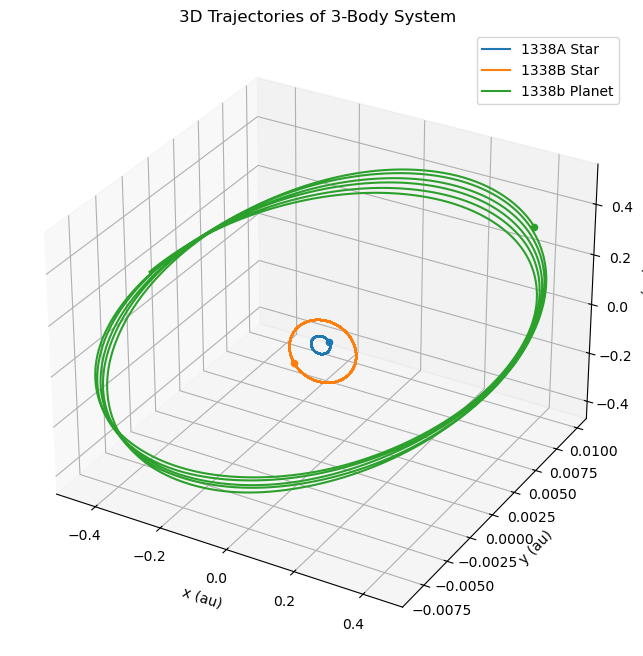

In [47]:
# 3D plot of trajectories
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot trajectories
ax.plot(r1_traj[:, 0], r1_traj[:, 1], r1_traj[:, 2], label='1338A Star')
ax.plot(r2_traj[:, 0], r2_traj[:, 1], r2_traj[:, 2], label='1338B Star')
ax.plot(r3_traj[:, 0], r3_traj[:, 1], r3_traj[:, 2], label='1338b Planet')

# Plot starting points
ax.scatter(r1_traj[0, 0], r1_traj[0, 1], r1_traj[0, 2], marker='o')
ax.scatter(r2_traj[0, 0], r2_traj[0, 1], r2_traj[0, 2], marker='o')
ax.scatter(r3_traj[0, 0], r3_traj[0, 1], r3_traj[0, 2], marker='o')

ax.set_xlabel('x (au)')
ax.set_ylabel('y (au)')
ax.set_zlabel('z (au)')
ax.set_title('3D Trajectories of 3-Body System')
ax.legend()

plt.show()

### *Comparison Method: IAS15 Integrator*

In [48]:

def run_ias15(t_final_days=500, steps=5000):
    sim = rebound.Simulation()
    sim.integrator = "ias15"
    sim.units = ('AU', 'day', 'Msun')
    sim.G = G

    sim.add(m=MA, x=r1_0[0], y=r1_0[1], z=r1_0[2], vx=v1_0[0], vy=v1_0[1], vz=v1_0[2])
    sim.add(m=MB, x=r2_0[0], y=r2_0[1], z=r2_0[2], vx=v2_0[0], vy=v2_0[1], vz=v2_0[2])
    sim.add(m=MP, x=r3_0[0], y=r3_0[1], z=r3_0[2], vx=v3_0[0], vy=v3_0[1], vz=v3_0[2])

    times = np.linspace(0, t_final_days, steps + 1)
    y_vals = np.zeros((len(times), 18))

    for i, t in enumerate(times):
        sim.integrate(t)
        state = []
        for p in sim.particles:
            state.extend([p.x, p.y, p.z, p.vx, p.vy, p.vz])
        y_vals[i] = np.array(state)

    return times, y_vals

In [49]:
def interpolate_solution(t_source, y_source, t_target):
    y_interp = np.zeros((len(t_target), y_source.shape[1]))
    for j in range(y_source.shape[1]):
        y_interp[:, j] = np.interp(t_target, t_source, y_source[:, j])
    return y_interp

In [50]:
t_ias15, y_ias15 = run_ias15(t_final_days=tf, steps=5000)
y_ias15_interp = interpolate_solution(t_ias15, y_ias15, t_values)

### *Trajectory Comparison*

In [51]:
def compute_max_position_error(y_rk4, y_ref):
    n_times = y_rk4.shape[0]
    n_bodies = y_rk4.shape[1] // 6

    errors = np.zeros(n_times)

    for k in range(n_times):
        max_err = 0
        for i in range(n_bodies):
            r_rk4 = y_rk4[k, i*6:i*6+3]
            r_ref = y_ref[k, i*6:i*6+3]
            err = np.linalg.norm(r_rk4 - r_ref)
            max_err = max(max_err, err)
        errors[k] = max_err

    return errors

pos_errors = compute_max_position_error(y_rk4, y_ias15_interp)

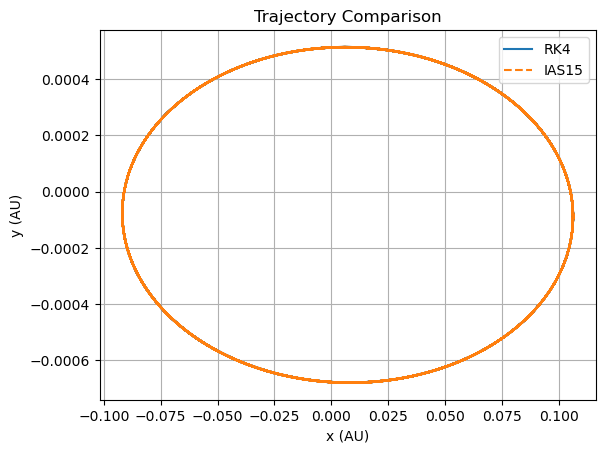

In [52]:
# Earth = particle 1 → indices 6:9
plt.plot(y_rk4[:, 6], y_rk4[:, 7], label="RK4")
plt.plot(y_ias15_interp[:, 6], y_ias15_interp[:, 7], '--', label="IAS15")

plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.legend()
plt.title("Trajectory Comparison")
plt.grid()
plt.show()

### *Error between Methods*

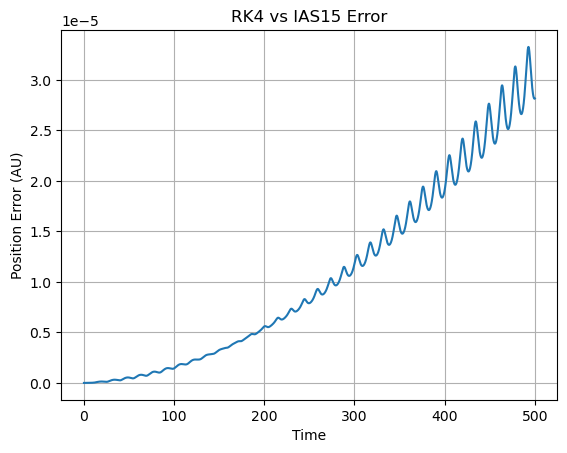

In [53]:
plt.plot(t_values, pos_errors)
plt.xlabel("Time")
plt.ylabel("Position Error (AU)")
plt.title("RK4 vs IAS15 Error")
plt.grid()
plt.show()

### *Convergance Test*

In [54]:

h_values = [5, 2.5, 1.25, 0.625]
errors = []

t_ref, y_ref = run_ias15(t_final_days=tf, steps=20000)

for h in h_values:
    t_rk4, y_rk4 = integrate_rk4(three_body_derivatives, y0, t0, tf, h, masses)
    y_ref_interp = interpolate_solution(t_ref, y_ref, t_rk4)
    err = np.linalg.norm(y_rk4[-1] - y_ref_interp[-1], ord=np.inf)
    errors.append(err)

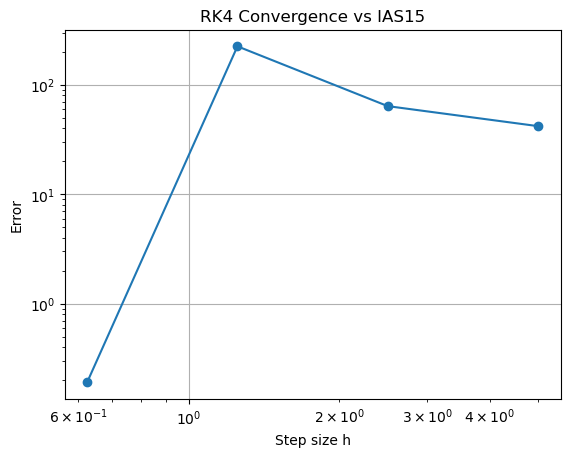

In [55]:
plt.loglog(h_values, errors, 'o-')
plt.xlabel("Step size h")
plt.ylabel("Error")
plt.title("RK4 Convergence vs IAS15")
plt.grid()
plt.show()

Using Impact Parameters to verify models against known data

In [56]:
Rsun_au = 0.00465047
R1 = 1.331 * Rsun_au

def b_xy_from_state(state):
    rs = state[0:3]  # Star A position (final state)
    rp = state[12:15]  # Planet position (final state)
    d_xy = np.linalg.norm(rp[[0,1]] - rs[[0,1]])  # XY projected distance
    return d_xy / R1

BJD_ref = 2455186.0
targets = [
    (2458861.1845, 0.143),
    (2458954.1353, 0.206),
    (2459049.6930, -0.006),
    (2459142.3991, 0.055),
]

print(f"{'BJD':<13} | {'RK4':<12} | {'IAS15':<12} | {'Table 6':<8}")
print('-'*68)

for target_bjd, table_b in targets:
    t_target = target_bjd - BJD_ref
    _, state_rk4 = integrate_rk4(three_body_derivatives, y0, 0.0, t_target, 0.1, masses)
    _, state_ias = run_ias15(t_final_days=t_target, steps=5000)
    
    br_xy = b_xy_from_state(state_rk4[-1])
    bi_xy = b_xy_from_state(state_ias[-1])

    error_ias = abs((bi_xy - table_b) / table_b) * 100
    error_rk4 = abs((br_xy - table_b) / table_b) * 100
    
    print(f"{target_bjd:<13.4f} | {br_xy:<12.6f} | {bi_xy:<12.6f} | {table_b:<8.3f} | RK4 Error: {error_rk4:.2f}% | IAS15 Error: {error_ias:.2f}%")

BJD           | RK4          | IAS15        | Table 6 
--------------------------------------------------------------------
2458861.1845  | 0.487745     | 0.163723     | 0.143    | RK4 Error: 241.08% | IAS15 Error: 14.49%
2458954.1353  | 0.272345     | 0.212012     | 0.206    | RK4 Error: 32.21% | IAS15 Error: 2.92%
2459049.6930  | 0.511485     | 0.039434     | -0.006   | RK4 Error: 8624.75% | IAS15 Error: 757.24%
2459142.3991  | 0.749172     | 0.148331     | 0.055    | RK4 Error: 1262.13% | IAS15 Error: 169.69%
